# Seminars 9&10

## Linear regression

Advantages:

*   Easy to use (not many hyperparameters to tune)
*   Easy to interpret (why does the model predict this value?)
*   More compex algorithms are based on it
*   Do not require a lot of resources (fast computation, not a lot of memory)
*  Has probabilistic interpretation (can test hypothesis, compute confidence intervals)



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Let's work with data about sales and advertisements.


*   *Sales* - sales of a product (in thousands of items);
*   *TV* - money spent on advertisements on TV (in thousands of dollars);
*   *Radio* - money spent on advertisements on radio (in thousands of dollars);
*   *Newspaper* - money spent on advertisements in newspapers (in thousands of dollars);



In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/hse-python-mirec/dap_mirec_2022/main/seminar9/Advertising.csv', index_col=0)
data.head()

*Sales* - **target** variable. We are going to check, how other variables influence it.

*TV, Radio, Newspaper* - **features**, which may influence the target.

In [ ]:
plt.hist(data['Sales']);

In [ ]:
data.shape

We have 200 samples in the dataset.

Let's visually check if there are dependencies.

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
ax1 = data.plot(kind='scatter', x='TV', y='Sales', ax=axs[0], c='deepskyblue')
ax2 = data.plot(kind='scatter', x='Radio', y='Sales', ax=axs[1], c='palevioletred')
ax3 = data.plot(kind='scatter', x='Newspaper', y='Sales', ax=axs[2], c='yellowgreen')
ax1.title.set_text('Dependence of sales on TV advertising')
ax2.title.set_text('Dependence of sales on radio advertising')
ax3.title.set_text('Dependence of sales on newspaper advertising')
plt.show()

The company will want to know, how to spend money on advertisements in the future.

This general question may lead you to more specific questions:



*   Is there a connection between advertisements and sales?
*   How strong is the connection?
*   Which type of advertisement is the most effective?
*   Can we predict sales given the expenses on each type of the advertisements?

Let's try to do it



## Simple Linear Regression

Simple linear regression (SLR) is a linear regression model with a single feature
$y = \beta_0 + \beta_1 x$


*   $y$ - target (numerical)
*   $x$ - feature (numerical)
*   $\beta_0$ - intercept
*   $\beta_1$ - coefficient of the independent variable $x$

So, we want to draw a straight line on the scatterplot that reflect data the best.

$\beta_0, \beta_1$ - **coefficients of the model**. The model learn their values during training.



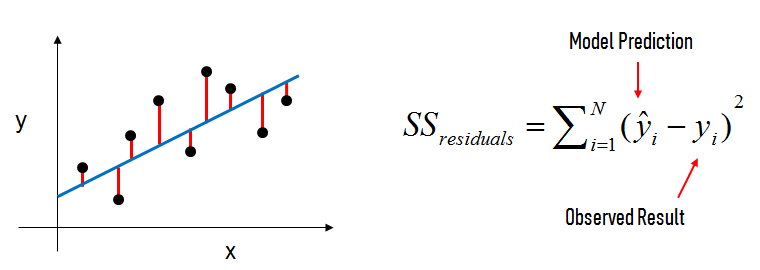


In the figure above:

*   Points are the data we have
*   Blue line - the model
*   Red lines - residuals

Coefficients of the model are:

*   $\beta_0$ - point where the line interset Oy (where $x=0$)
*   $\beta_1$ - the slope of the line





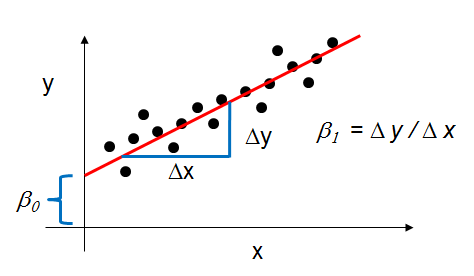

**Task** Let's try fitting linear regression manually, find the $\beta_1$, $\beta_0$ (try different numbers, like 0, 1, 0.5, etc.)

In [ ]:
b_0 = #your code here
b_1 = #your code here

plt.scatter(data['TV'], data['Sales'], c='deepskyblue', label='TV')
x_space = np.arange(data['TV'].min(), data['TV'].max(), 0.1)
plt.plot(x_space, x_space * b_1 + b_0, label=r'y='+str(b_1) + 'x +' + str(b_0))

plt.legend()
plt.show()

### Fitting the model

Let's build the linear regression using `statsmodels` library. Let's check, how sales depend on TV

Did we find similar numbers?

In [ ]:
import statsmodels.formula.api as smf

#create the model using the formula and the data.fit()
lm = smf.ols(formula='Sales ~ TV', data=data).fit()

#coefficients
lm.params

`formula` argument need to contain the formula we want to use, the string `'Sales ~ TV'` means $Sales = \beta_0 + \beta_1 TV$.


More info about formulas can be found [here](https://patsy.readthedocs.io/en/latest/formulas.html).

### Interpreting the model

Let's interpret the coefficients:

If no money is spend on TV advertisement, the Sales are 7.032594. Additional 1 000 \$ on TV advertisements will increase Sales by 47.537 items.


Note: if increasing TV advertisements had lead to decreasing Sales, the coefficient $\beta_1$ would have been negative.

### Predicting

Let's try to predict Sales.

**Task** Company decided to spend 50 (thousand dollars) on TV advertisement, how many goods will they sall?

Use the formula:

$y = \beta_0 + \beta_1 TV$



In [ ]:
y = #your code here
y

We also can use the model from the library:

In [ ]:
# the model take DataFrame as input, so we need to construct it
X_new = pd.DataFrame({'TV': [50]})

# use the model to make predictions on a new value
lm.predict(X_new)

### Visualizing

Let's plot the line. We can predict for the smallest and biggest values and connect the points

In [ ]:
X_new = pd.DataFrame({'TV': [data.TV.min(), data.TV.max()]})
X_new.head()

In [ ]:
preds = lm.predict(X_new)
preds

In [ ]:
plt.figure(figsize=(6, 4))
plt.title('Visualizing the predictions')

plt.scatter(data.TV, data.Sales, c='deepskyblue')
plt.plot(X_new, preds,  linewidth=2)
plt.ylabel('Sales')
plt.xlabel('TV')
plt.show()

**Questions**:



*   Is the fitted model better than manually chosen coefficents?
*   Does the linear model agree with data well?
*   Can we spot any difficulties?

All in all, is the model good?



## Loss functions, Metrics

In [ ]:
lm = smf.ols(formula='Sales ~ TV', data=data).fit()
pred = lm.predict(data['TV'])



Mean squared error:

$$MSE(y, \hat{y}) = \frac{1}{l}\sum_{i=1}^l (y_i - \hat{y_i})^2$$


**Task** Compute $MSE$


In [ ]:
def mse_func(y_true, y_pred):
  #your code here

mse = mse_func(data['Sales'], pred)
mse

Question: which difficulty we may face when trying to interpret $MSE$?

Root mean squared error:

$$RMSE(y, \hat{y}) = \sqrt{MSE(y, \hat{y})}$$


**Task** Compute $RMSE$

In [ ]:
def rmse_func(y_true, y_pred):
  #your code here

rmse = rmse_func(data['Sales'], pred)
rmse

Mean absolute error:

$$MAE(y, \hat{y}) = \frac{1}{l}\sum_{i=1}^l |y_i - \hat{y_i}|$$

**Task** Compute $MAE$

In [ ]:
def mae_func(y_true, y_pred):
  #your code here

mae = mae_func(data['Sales'], pred)
mae

Question: which difficulty we may face when trying to interpret $MSE/RMSE/MAE$?

Hint: is $RMSE=3$ good for all datasets?

Coefficient of determination (also called R-squared):

$$R^2 = 1 - \frac{\sum_i(y_i - \hat{y}_i)^2}{\sum_i(y_i - \overline{y})^2}$$





*   Close to 1 - good model
*   Close to 0 - model works as the model that predicts using average target (no features used)
*   Negative - model is bad (worse than average target - something is really wrong)

**Task** Compute $R^2$



In [ ]:
def r_2_func(y_true, y_pred):
  #your code here

r_2 = r_2_func(data['Sales'], pred)
r_2

Depict all errors:

In [ ]:
def report(y_true, y_pred):
  print('R^2 =  {}'.format(r_2_func(y_true, y_pred)))
  print('MSE =  {}'.format(mse_func(y_true, y_pred)))
  print('RMSE =  {}'.format(rmse_func(y_true, y_pred)))
  print('MAE =  {}'.format(mae_func(y_true, y_pred)))

report(data['Sales'], pred)

**Question** Is the model good?

Let's compare to the model, that predicts just by averaging:



In [ ]:
report(data['Sales'], data['Sales'].mean())

And model, that we created manually:

In [ ]:
report(data['Sales'], data['TV'] * b_1 + b_0)

**Question** Which model is better?

In [ ]:
plt.scatter(data.TV, data.Sales, c='deepskyblue')
plt.plot(data['TV'], lm.predict(data),  linewidth=2, label='Fitted Model')
plt.plot(data['TV'], data['TV'] * b_1 + b_0,  linewidth=2, label='Manual Model')
plt.plot(data['TV'], np.zeros(len(data))+data['Sales'].mean(),  linewidth=2, label='Avg Model')
plt.ylabel('Sales')
plt.xlabel('TV')
plt.legend()
plt.show()

## Multiple linear regression

Now, let's check if Sales depend on many features.

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_d x_d$

where $x_1, ..., x_d$ are the features of a sample

For our data:

$Sales = \beta_0 + \beta_1 \times TV + \beta_2 \times Radio + \beta_3 \times Newspaper$

In [ ]:
lm = smf.ols(formula='Sales ~ TV + Radio + Newspaper', data=data).fit()

lm.params

Weight for $TV$ used to be $0.047537$ and it changed a bit - other features are taken into account.

We have a new model, let's check the metrics:

In [ ]:
pred = lm.predict(data)

report(data['Sales'], pred)

All the metrics are better, is seems that this new model is better at *explaining* the Sales.

## Importance of features

In our model the coefficient for Newspaper is negative, so advertisements in Newspaper decrease the Sales. This may seem illogical. Why did this happen?


Because coefficients are calculating using data and it is noisy. The coefficients are random variables, so it may be an accident.


Let's check the summary about the model that helps to draw conclusions about the feature.

In [ ]:
lm.summary()

The 95\% confidence interval for Newspaper contain 0, so, it is likely that this feature has no real influence on the Sales.

**Task** Conduct an experiment - add 3 random features to the data and fit a model

Expectations?

In [ ]:
np.random.seed(0)

data_new = data.copy()
#This will be from normal with loc(mu)=5
data_new['Random1'] = #your code here

#THis will be from uniform
data_new['Random2'] = #your code here

#This will be from normal with loc(mu)=3
data_new['Random3'] = #your code here

lm = smf.ols(formula='#your code here', data=data_new).fit()
lm.summary()

We can see, that the random features are still assigned some coefficients because model - and some of them are bigger than coef for good features.

In [ ]:
#checking that there is no real dependency for Random and Sales
plt.scatter(data_new['Random1'], data_new['Sales']);

Let's check correlation:

In [ ]:
sns.heatmap(data_new.corr(numeric_only=True), annot=True, fmt='.2f');

In [ ]:
data_new.describe()

**Question** What can we say about correlation of real and random features with target?

Why weights were assigned to the random features and why they are big:


*   Model does not detect that the feature is random/useless, it uses all the given features
*   There is some timy correlation between random features and target, so the model will assign some weight to them
*   Scale of the random features are small, so the weight is big to compensate



Importance of scale:

Consider the example model $y = 1000x_1 + 1 x_2$

The coefficent for the featrue $x_1$ is significanlty bigger, so the feature $x_1$ seems to be more important, but $x_1 \in [0.001, 0.3]$ (weight of a person in tons) and $x_2 \in [200, 2000]$ (height of the person in mm)

If we change the scales: kgs instead of tons and cm instead of mm, the model will look like $y = 1x_1' + 10x_2'$, so the feature 2 will seem more important.

In our example:

In [ ]:
def show_weights(X, features, weights):
    weights = weights[features]
    means, scales = X[features].mean(), X[features].std()
    fig, axs = plt.subplots(figsize=(14, 10), ncols=3)
    sorted_weights = sorted(zip(weights, features, means, scales), reverse=True)
    weights, features, means, scales = zip(*sorted_weights)
    features = list(features)

    sns.barplot(y=features, x=list(weights), ax=axs[0])
    axs[0].set_xlabel("Weight")
    sns.barplot(y=features, x=list(means), ax=axs[1])
    axs[1].set_xlabel("Mean")
    sns.barplot(y=features, x=list(scales), ax=axs[2])
    axs[2].set_xlabel("Scale")
    plt.tight_layout()

features = lm.params.index.tolist()
features.pop(0)
show_weights(data_new, features, lm.params)

It may seem that Random1 is the most important feature because the absolute value of the coefficient is bigger BUT the features may have diffent scales and it will influence the  result.

Let's change the scale of Radio (the coefficent was big), it is in thousands of dollars now, but what if we had it just in dollars?

In [ ]:
data_new['Radio_dollars'] = data_new['Radio'] * 1_000
lm = smf.ols(formula='Sales ~ TV + Radio_dollars + Newspaper + Random1 + Random2 + Random3', data=data_new).fit()

features = lm.params.index.tolist()
features.pop(0)
show_weights(data_new, features, lm.params)

Now, the coefficient is tiny comapred to others.


What may we do? We may scale features (f. e. using z score) - the mean will be 0 and std 1 for all features

In [ ]:
from scipy.stats import zscore

for feat in features:
  data_new[feat] = zscore(data_new[feat])
data['Radio'] = zscore(data_new['Radio'])

lm = smf.ols(formula='Sales ~ TV + Radio + Newspaper + Random1 + Random2 + Random3', data=data_new).fit()

features = lm.params.index.tolist()
features.pop(0)
show_weights(data_new, features, lm.params)

In [ ]:
lm.params

Now, the scales of all features and it is possible to compare.

## Categorical features

We worked with numerical features, but what about categorical?

For example, we may have information if the market is in urban, suburban or rural area.

In [ ]:
np.random.seed(2025)
data['Area'] = 'rural'
data.loc[np.random.choice(np.where(data['Sales'] > 10)[0] + 1, size=53, replace=False), 'Area'] = 'suburban'
data.loc[np.random.choice(np.where(data['Sales'] > 15)[0] + 1, size=27, replace=False), 'Area'] = 'urban'

data['Area'].value_counts()

Sales seem to be different in different areas.

In [ ]:
sns.histplot(data, x='Sales', hue='Area')

How to add it to the model?

Idea #1 (Ordinal encoding): Let's just replace categories with some number (like rural - 0, suburban - 1, urban - 2)

Problem: assume rural < suburban < urban, the order may not be there. It may work for ordinal, but not for nominal.




In [ ]:
data['Area_ordinal'] = np.zeros(len(data))
data.loc[data['Area'] == 'suburban', 'Area_ordinal'] = 2
data.loc[data['Area'] == 'urban', 'Area_ordinal'] = 1

data.sample(4)

In [ ]:
lm = smf.ols(formula='Sales ~ TV + Radio + Newspaper + Area_ordinal', data=data).fit()

pred = lm.predict(data)

report(data['Sales'], pred)

lm.params

Idea #2 (One hot encoding): For every category create a separate feature, that is 1 if the sample has the category (features 'Area_rural', 'Area_suburban', 'Area_rural')

In [ ]:
data['Area_rural'] = (data['Area'] == 'rural').astype('int')
data['Area_suburban'] = (data['Area'] == 'suburban').astype('int')
data['Area_urban'] = (data['Area'] == 'urban').astype('int')
data.sample(4)

Possible problem: excessive information. Easy to see, that these features will always contain one 1 and two 0. So, we do not really need all 3.

In [ ]:
data.drop(columns=['Area_rural', 'Area_suburban', 'Area_urban', 'suburban', 'urban'], inplace=True, errors='ignore')

#Easier way to get OHE
area_dummies = pd.get_dummies(data.Area).iloc[:, 1:]

data = pd.concat([data, area_dummies], axis=1)
data.head()

In [ ]:
lm = smf.ols(formula='Sales ~ TV + Radio + Newspaper + suburban + urban', data=data).fit()

report(data['Sales'], lm.predict(data))

lm.params

## Sklearn

Library for machine learning.

Documentation is [here](https://scikit-learn.org/stable/).



*   ML models (Linear regression, ...)
*   Metrics (MSE, MAE, ...)
*   Preprocessing (scalers, encoders)
*   Other useful things



If we are using preprocessor we need to:

* Create it and specify hyperparameters
* `fit` - compute statistics, unique categories, etc
* `transform` - get the new features

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Encoder from sklearn
ohe = OneHotEncoder(drop='first')
#fit the encoder
ohe.fit(data[['Area']])
#transform data
X_categorical = ohe.transform(data[['Area']]).toarray()


#Scaler from sklearn
sc = StandardScaler()
sc.fit(data[['Newspaper', 'Radio', 'TV']])
X_numerical = sc.transform(data[['Newspaper', 'Radio', 'TV']])

y = data['Sales']
X = np.concatenate([X_numerical, X_categorical], axis=1)

X.shape

If we are using model we need to:

* Create it and specify hyperparameters
* `fit` - compute weights
* `predict` - predict the target

Linear regression form sklearn

In [ ]:
lr = LinearRegression()
lr.fit(X, y)
y_pred  = lr.predict(X)


#function from sklearn
mean_squared_error(y, y_pred)

## Overfitting

Let's consider an example: $y = cos(1.5\pi x)$ (the real dependency)

There is always some noise in the real data, so $\tilde{y}_i = y(x_i) + \mathcal{N}(0, 0.01)$.



In [ ]:
np.random.seed(36)

#true function
x = np.linspace(0, 1, 100)
y = np.cos(1.5 * np.pi * x)

#observations
x_objects = np.random.uniform(0, 1, size=30)
y_objects = np.cos(1.5 * np.pi * x_objects) + np.random.normal(scale=0.1, size=x_objects.shape)

plt.scatter(x_objects, y_objects)
plt.plot(x, y)

Let's fir linear regression:

In [ ]:
regr = LinearRegression().fit(x_objects.reshape((-1, 1)), y_objects)

print('MSE = ', mean_squared_error(y_objects, regr.predict(x_objects.reshape((-1, 1)))))

plt.scatter(x_objects, y_objects)
plt.plot(x, y)
plt.plot(x, regr.predict(x.reshape((-1, 1))), label='Prediction')

plt.legend()

How can we make it better? Can we add more features?

Common technique is adding polynomial and interaction features: features [a, b] + degree=2 will be features [1, a, b, a^2, ab, b^2]

Let's try  using $\{x, x^2, x^3, x^4\}$ (add features to degree 4)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures


degree = 4
X_objects = PolynomialFeatures(degree, include_bias=False).fit_transform(x_objects[:, None])
X = PolynomialFeatures(degree, include_bias=False).fit_transform(x[:, None])
regr = LinearRegression().fit(X_objects, y_objects)
y_pred = regr.predict(X)
print('MSE = ', mean_squared_error(y_objects, regr.predict(X_objects)))

plt.plot(x, y, label="Real function")
plt.scatter(x_objects, y_objects, label="Data")
plt.plot(x, y_pred, label="Prediction")

plt.legend()

Looks excellent! 4 seems to be a very good degree for this data.

But that if we add more? Like $\{x, \dots, x^{20}\}$

In [ ]:
degree = 20
X_objects = PolynomialFeatures(degree, include_bias=False).fit_transform(x_objects[:, None])
X = PolynomialFeatures(degree, include_bias=False).fit_transform(x[:, None])
regr = LinearRegression().fit(X_objects, y_objects)
y_pred = regr.predict(X)
print('MSE = ', mean_squared_error(y_objects, regr.predict(X_objects)))

plt.plot(x, y, label="Real function")
plt.scatter(x_objects, y_objects, label="Data")
plt.plot(x, y_pred, label="Prediction")
plt.ylim(-2, 2)
plt.legend()

What is going on? - Overfitting: good results on the training data, bad on new (test)


How to spot - check the test data + big coefficients

In [ ]:
regr.coef_

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_objects[:, None], y_objects, test_size=0.3, random_state=0)

In [ ]:
def poly_fit(degree):
  pf = PolynomialFeatures(degree, include_bias=False).fit(X_train)

  X_train_pf = pf.transform(X_train)
  X_test_pf  = pf.transform(X_test)

  regr = LinearRegression().fit(X_train_pf, y_train)
  y_pred_train = regr.predict(X_train_pf)
  y_pred_test  = regr.predict(X_test_pf)

  X = pf.transform(x[:, None])
  y_pred = regr.predict(X)
  print('Degree is', degree)
  print('Train MSE = ', mean_squared_error(y_train, y_pred_train))
  print('Test  MSE = ', mean_squared_error(y_test,  y_pred_test))

  plt.title('Degree is ' + str(degree))
  plt.plot(x, y, label="Real function")
  plt.scatter(X_train[:,0], y_train, label="Train data")
  plt.scatter(X_test[:,0], y_test, label="Test  data")
  plt.plot(x, y_pred, label="Prediction")
  plt.ylim(-2, 2)
  plt.legend();

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
poly_fit(1)

plt.subplot(1, 3, 2)
poly_fit(4)

plt.subplot(1, 3, 3)
poly_fit(20)



*   Underfitted model has big train and test error: it cannot predict both train and test good
*  Good-fit model has comparable train and test error (train may be a bit smaller)^ it can predict seen and new data fine, because it learned real dependencies
*  Overfitted model has small train error and big test error: it remembers train data and cannot generalise


Example: the model should predict the Happiness index of the country ([source](https://www.theglobaleconomy.com/rankings/happiness/))



*   Underfitted model - all countries have index = 2
*   Good-fit model takes into account laws, availibility of water, food and education, state of economics
*  Overfitted model - country named "Belgium" has 6.89, country named "Argentina" has 6.19





How to tackle overfitting? Use regularization

## Regularization

### L2

$L_2$-regularization:

$Q_{reg}(X, y, a) = Q(X, y, a) +  \alpha \|w\|_2^2$




where $Q(X, y, a)$ is the loss function used in the model (MSE in linear regression) and $w$ are the coefficients of the model

$\alpha$ - the **hyperparameter** - the strength of the regularization (the bigger, the more strong)

Why the regularization penalize big weights? Overfited models have too large coefficents

Why overfitted models usually have big coefficents? Because they play around with weights to make the prediction for train data exact (big values cancel each other)

In [ ]:
regr.coef_

And usually coefficents should not be so big.

For example, $grade\_of\_student = 1000hours\_slept\_at\_night + 123123453hours\_studied - 3454535hours\_played\_video\_games + ...$

The coefficents as suspicious: a student will sleep additional hour and their grade will increase by 1000...

More plausible formula will be $grade\_of\_student = 0.5hours\_slept\_at\_night + 0.3hours\_studied - 0.4hours\_played\_video\_games + ...$ - student sleeps additional hour and their grade is $0.5$ bigger.

Let's apply $L_2$ regularization to our data with power 20. In sklearn it is called [Ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

In [ ]:
pf = PolynomialFeatures(20, include_bias=False).fit(X_train)
X_train_pf = pf.transform(X_train)
X_test_pf  = pf.transform(X_test)

In [ ]:
from sklearn.linear_model import Ridge

alpha = 10 #some random value

regr = Ridge(alpha=alpha).fit(X_train_pf, y_train)

y_pred_train = regr.predict(X_train_pf)
y_pred_test  = regr.predict(X_test_pf)
X = pf.transform(x[:, None])
y_pred = regr.predict(X)

print('Train MSE = ', mean_squared_error(y_train, y_pred_train))
print('Test  MSE = ', mean_squared_error(y_test,  y_pred_test))
print(regr.coef_)

plt.plot(x, y, label="Real function")
plt.scatter(X_train[:,0], y_train, label="Train data")
plt.scatter(X_test[:,0], y_test, label="Test  data")
plt.plot(x, y_pred, label="Prediction")
plt.ylim(-2, 2)
plt.legend();

The reqults are better, but not as good as for degree 4, maybe $\alpha = 10$ is not a good value

If $\alpha$ is too small, almost no regularization

If $\alpha$ is too big, the regularization will be too strong

In [ ]:
def fit_ridge(alpha, print_coefs=False):
  regr = Ridge(alpha=alpha).fit(X_train_pf, y_train)

  y_pred_train = regr.predict(X_train_pf)
  y_pred_test  = regr.predict(X_test_pf)
  X = pf.transform(x[:, None])
  y_pred = regr.predict(X)
  print('alpha =', alpha)
  print('Train MSE = ', mean_squared_error(y_train, y_pred_train))
  print('Test  MSE = ', mean_squared_error(y_test,  y_pred_test))
  if print_coefs: print(regr.coef_)

  plt.plot(x, y, label="Real function")
  plt.scatter(X_train[:,0], y_train, label="Train data")
  plt.scatter(X_test[:,0], y_test, label="Test  data")
  plt.plot(x, y_pred, label="Prediction")
  plt.title(r'Ridge $\alpha$ = '+str(alpha))
  plt.ylim(-2, 2)
  plt.legend();

In [ ]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 6, 1)
fit_ridge(0)

plt.subplot(1, 6, 2)
fit_ridge(0.01)

plt.subplot(1, 6, 3)
fit_ridge(0.1)


plt.subplot(1, 6, 4)
fit_ridge(1)

plt.subplot(1, 6, 5)
fit_ridge(10)

plt.subplot(1, 6, 6)
fit_ridge(20)

### Hyperparameters

What is $\alpha$? How to choose which to set (not too big, not too small)?

$\alpha$ is a **hyperparameter** - a value that defines a learning process of a model and is set before the training

How to choose it?



*   (sometimes) it is possible to assume based on the area/task/data
*   USE AND CHECK the quality of the model



In [ ]:
alpha_list = np.logspace(-5, 2, 100)
alpha_list

In [ ]:
mse_list_train = []
mse_list_test  = []

for alpha in alpha_list:
  regr = Ridge(alpha=alpha).fit(X_train_pf, y_train)
  mse_list_train.append(mean_squared_error(y_train, regr.predict(X_train_pf)))
  mse_list_test .append(mean_squared_error(y_test,  regr.predict(X_test_pf )))


plt.plot(alpha_list, mse_list_train, label='Train')
plt.plot(alpha_list, mse_list_test,  label='Test')
plt.title(r'MSE with respect to $\alpha$')
plt.legend()
plt.show()

We need to choose $\alpha$ that gives the best quality on test data:

In [ ]:
alpha_list[np.argmin(mse_list_test)]

In [ ]:
fit_ridge(alpha_list[np.argmin(mse_list_test)])

Why test, not train? For train data the smallest $\alpha$ possible will be the best, because it will allow to overfit and get the best quality on train possible.


In [ ]:
alpha_list[np.argmin(mse_list_train)] #smallest alpha

In [ ]:
fit_ridge(alpha_list[np.argmin(mse_list_train)], print_coefs=True)


Hyperparameters cannot be chosen by quality on train data. We always need additional sample.

Actually, train data is often split into train and validation data

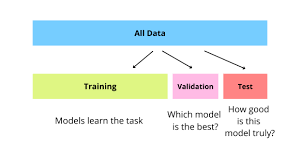

So, each partition has a purpose:


*   Train - this data will be used by the model to learn (to be fitted)
*   Validation - to check how the current model performs on new data (set hyperparameter - fit on train - test on validation, repeat, choose the best model)
*   Test - to check the quality of one final model (real life setting)



In [ ]:
X_train_, X_test, y_train_, y_test = train_test_split(x_objects[:, None], y_objects, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train_, y_train_, test_size=0.1, random_state=7)

In [ ]:
pf = PolynomialFeatures(20, include_bias=False).fit(X_train)

X_train_pf = pf.transform(X_train)
X_val_pf  = pf.transform(X_val)
X_test_pf  = pf.transform(X_test)

In [ ]:
mse_list_train = []
mse_list_val  = []

for alpha in alpha_list:
  #Fit on train
  regr = Ridge(alpha=alpha).fit(X_train_pf, y_train)
  mse_list_train.append(mean_squared_error(y_train, regr.predict(X_train_pf)))
  #checking on validation
  mse_list_val .append(mean_squared_error(y_val,  regr.predict(X_val_pf)))

plt.plot(alpha_list, mse_list_train, label='Train')
plt.plot(alpha_list, mse_list_val,  label='Validation')
plt.title(r'MSE with respect to $\alpha$')
plt.legend()
plt.show()

In [ ]:
best_alpha = alpha_list[np.argmin(mse_list_val)]
best_alpha

In [ ]:
fit_ridge(best_alpha, print_coefs=True)

For this particular dataset the best $\alpha$ is 1.6e-05, but there is no garantee that it will be good for another dataset - need to check again.

### L1

THere is different type of regularisation - $L_1$. It utilizes the same idea as $L_2$, but use absolute velues instead of squares. The formulas are a bit trickier.

 $Q_{reg}(X, y, a) = \sum_{i=1}^l (y_i - wx_i)^2 + \lambda \sum_{j=1}^d |w_j| \rightarrow min_{w} $

In sklearn it is called [Lasso regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

In [ ]:
from sklearn.linear_model import Lasso

def fit_lasso(alpha, print_coefs=False):
  regr = Lasso(alpha=alpha).fit(X_train_pf, y_train)

  y_pred_train = regr.predict(X_train_pf)
  y_pred_test  = regr.predict(X_test_pf)
  X = pf.transform(x[:, None])
  y_pred = regr.predict(X)
  print('alpha =', alpha)
  print('Train MSE = ', mean_squared_error(y_train, y_pred_train))
  print('Test  MSE = ', mean_squared_error(y_test,  y_pred_test))
  if print_coefs: print(regr.coef_)

  plt.plot(x, y, label="Real function")
  plt.scatter(X_train[:,0], y_train, label="Train data")
  plt.scatter(X_test[:,0], y_test, label="Test  data")
  plt.plot(x, y_pred, label="Prediction")
  plt.title(r'Lasso $\alpha$ = '+str(alpha))
  plt.ylim(-2, 2)
  plt.legend();

Let's start with same $\alpha = 10$

In [ ]:
fit_lasso(10, print_coefs=True)

This value is too big for lasso - all coefficents are 0. (Even if different models have similar hyperparameters there is no garantee thay will work similary)

`alpha_list` is not a good grid of hyperparameters for lasso:

In [ ]:
mse_list_train = []
mse_list_val  = []

for alpha in alpha_list:
  #Fit on train
  regr = Lasso(alpha=alpha).fit(X_train_pf, y_train)
  mse_list_train.append(mean_squared_error(y_train, regr.predict(X_train_pf)))
  #checking on validation
  mse_list_val .append(mean_squared_error(y_val,  regr.predict(X_val_pf)))

plt.plot(alpha_list, mse_list_train, label='Train')
plt.plot(alpha_list, mse_list_val,  label='Validation')
plt.title(r'MSE with respect to $\alpha$')
plt.legend()
plt.show()

$\alpha$ becomes big too quickly (and the model will be constant)

In [ ]:
#to ignore warnings
import warnings
warnings.filterwarnings("ignore")

alpha_list = np.logspace(-10, -3, 100)

mse_list_train = []
mse_list_val  = []

for alpha in alpha_list:
  #Fit on train
  regr = Lasso(alpha=alpha).fit(X_train_pf, y_train)
  mse_list_train.append(mean_squared_error(y_train, regr.predict(X_train_pf)))
  #checking on validation
  mse_list_val .append(mean_squared_error(y_val,  regr.predict(X_val_pf)))

plt.plot(alpha_list, mse_list_train, label='Train')
plt.plot(alpha_list, mse_list_val,  label='Validation')
plt.title(r'MSE with respect to $\alpha$')
plt.legend()
plt.show()

In [ ]:
best_alpha = alpha_list[np.argmin(mse_list_val)]
best_alpha

In [ ]:
fit_lasso(best_alpha, print_coefs=True)

Lasso regression has cool ability - it sets weights of "useless" features to $0$ (Ridge will give small values like $1e-5$, but no 0)


**Task** Find $\alpha$ that gives only 1 non-zero weight

In [ ]:
alpha_1_nonzero = #your code here
fit_lasso(alpha_1_nonzero, print_coefs=True)

## Cross-validation

Problem with separate validation set: shrink the amount data to use for training.

Idea: let's split the data into $n$ folds of similar size and train the model $n$ times, each time - one fold is validation and other $n-1$ is trin set. Compute loss $n$ times and take average.

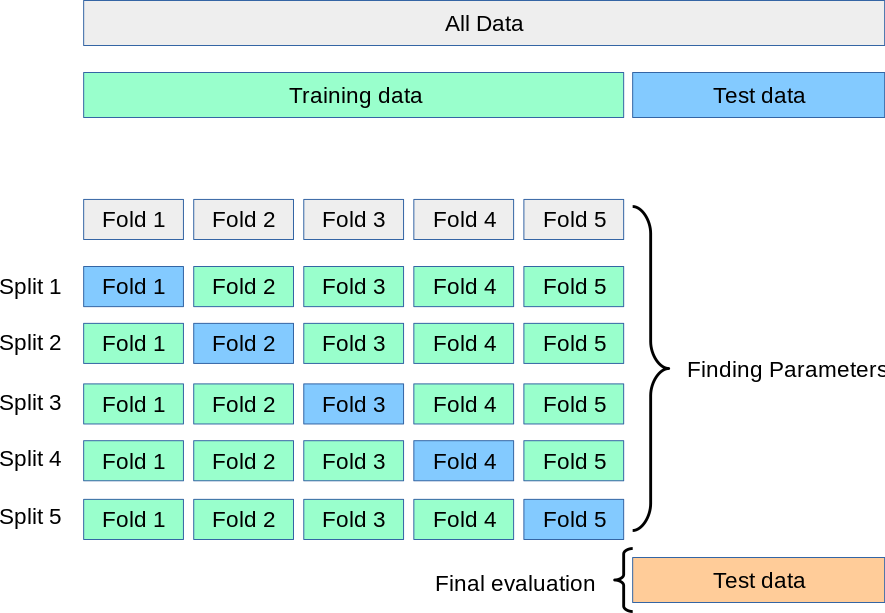

Common parameters: `cv` - number of folds (very often 5 or 10). `scoring` - what metric/loss to compute.

`verbose` - the level of printing the info about the process.(not about machine learning, but useful)

In [ ]:
X_train_pf = pf.transform(X_train_)

In [ ]:
from sklearn.model_selection import cross_val_score

c = cross_val_score(Ridge(alpha=10), X_train_pf, y_train_, cv=3, scoring='neg_mean_squared_error', verbose=7)
c

In [ ]:
-np.mean(c)

Cross-validation is useful for hyperparameter search: for every set of hyperparameters apply cross-validation and compute the quality. Choose the model with the best quality

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'alpha' : np.logspace(-5, 2, 100)}

clf = GridSearchCV(Ridge(), params, cv=3, scoring='neg_mean_squared_error')
clf.fit(X_train_pf, y_train_)

We can check the best hyperparameters:

In [ ]:
clf.best_params_

Or just use the fitted `GridSearchCV` object. The best model is saved there.

In [ ]:
mean_squared_error(y_test,  clf.predict(X_test_pf))

In [ ]:
plt.plot(x, y, label="Real function")
plt.scatter(X_train[:,0], y_train, label="Train data")
plt.scatter(X_test[:,0], y_test, label="Test  data")
plt.plot(x, clf.predict(X), label="Prediction")
plt.title(r'Ridge $\alpha$ = '+str(clf.best_params_['alpha']))
plt.ylim(-2, 2)
plt.legend();

**Task** Find best $\alpha$ for Lasso regression using cross-validation

In [ ]:
#your code here

**Question** Which model gave the best result? (Compare Ridge, Lasso with hyperparameters chosen by cross-validation and using validation set)